# Notebook 05 — Índice de Acessibilidade AE2SFCA

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva | **Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs

---
## Objetivo
Calcular o índice de acessibilidade **AE2SFCA** (areal) por setor censitário, nos modos
automóvel e pedestre, e a versão tradicional **E2SFCA** (centroide) para comparação (H1).
Identificar os setores classificados como "desertos de saúde".

## Entrada
| Arquivo | Origem |
|---|---|
| `intermediarios/05_isocronas/zonaUrbana_5km_isocronas_{carro,pedestre}.parquet` | NB 04 |
| `intermediarios/01_malha/teresina_setoresCensitarios_DadosCompletos.parquet` | NB 01.1 |

## Saída
| Arquivo | Consumido por |
|---|---|
| `processados/teresina_setores_acessibilidade.parquet` | NB 06 (testes H1/H2) |

> ⚠️ A **oferta (S_j)** está provisória (1 por UBS). Substituir pela capacidade real quando definida.
---

In [1]:
# ── 1. IMPORTAÇÕES ──────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from mapeprof.config import (INT_ISOCRONAS, INT_MALHA, PROCESSADOS,
                             FIGURAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import aplicar_estilo, barra_escala, seta_norte, moldura_mapa

aplicar_estilo(); warnings.filterwarnings("ignore"); criar_diretorios()
FIGURAS_NB = FIGURAS / "nb051"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
print("✅ Setup concluído.")

✅ Setup concluído.


In [2]:
# ── 2. CARGA E PARÂMETROS ───────────────────────────────────────────────────
setores = gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet").to_crs(CRS_METRICO)
setores = setores.rename(columns={"V01006_demog": "populacao"})
setores["populacao"]  = pd.to_numeric(setores["populacao"], errors="coerce").fillna(0)
setores["setor_area"] = setores.geometry.area

iso_carro = gpd.read_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_carro.parquet").to_crs(CRS_METRICO)
iso_pe    = gpd.read_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_pedestre.parquet").to_crs(CRS_METRICO)

PESOS = {10: 1.00, 20: 0.68, 30: 0.22}   # decaimento gaussiano (Luo; Qi, 2009)
OFERTA_POR_UBS = 1.0                      # ⚠️ S_j PROVISÓRIO — substituir pela capacidade real

print(f"🔄 {len(setores)} setores | pop {setores['populacao'].sum():,.0f} | "
      f"UBS {iso_carro['ubs_id'].nunique()}")

🔄 1403 setores | pop 820,940 | UBS 75


## 3. Cálculo do AE2SFCA areal

O método tem dois passos. No **Passo 1**, para cada UBS, soma-se a população de demanda
ponderada pela **fração de área** de cada setor contida em cada faixa isócrona e pelo peso
de decaimento da faixa; a razão oferta-demanda é `Rⱼ = Sⱼ / demanda`. No **Passo 2**, a
acessibilidade de cada setor é a soma das razões `Rⱼ` de todas as UBS que o alcançam,
novamente ponderadas pela fração areal e pelo decaimento. A sobreposição areal substitui
a inclusão por centroide, eliminando a premissa de que toda a população reside no centro
do setor.

In [3]:
# ── 3. FUNÇÃO AE2SFCA AREAL ─────────────────────────────────────────────────
def calcular_ae2sfca(isocronas, setores, oferta):
    iso = isocronas.copy()
    iso["w"] = iso["threshold_nominal"].map(PESOS)
    # Sobreposição areal: cada pedaço = (UBS, faixa, setor)
    pedacos = gpd.overlay(
        iso[["ubs_id", "threshold_nominal", "w", "geometry"]],
        setores[["CD_SETOR", "populacao", "setor_area", "geometry"]],
        how="intersection", keep_geom_type=True)
    pedacos["frac"] = pedacos.geometry.area / pedacos["setor_area"]      # fração areal I_jk
    # Passo 1: razão oferta-demanda por UBS
    pedacos["pop_pond"] = pedacos["populacao"] * pedacos["frac"] * pedacos["w"]
    Rj = (oferta / pedacos.groupby("ubs_id")["pop_pond"].sum()).replace([np.inf, -np.inf], np.nan)
    # Passo 2: acessibilidade por setor
    pedacos["contrib"] = pedacos["ubs_id"].map(Rj) * pedacos["w"] * pedacos["frac"]
    return pedacos.groupby("CD_SETOR")["contrib"].sum()

setores["acess_carro"] = setores["CD_SETOR"].map(calcular_ae2sfca(iso_carro, setores, OFERTA_POR_UBS)).fillna(0)
setores["acess_pe"]    = setores["CD_SETOR"].map(calcular_ae2sfca(iso_pe,    setores, OFERTA_POR_UBS)).fillna(0)
print(f"✅ AE2SFCA calculado | setores com acesso (carro): {(setores['acess_carro']>0).sum()} | "
      f"(pé): {(setores['acess_pe']>0).sum()}")

✅ AE2SFCA calculado | setores com acesso (carro): 1388 | (pé): 1356


## 4. Baseline tradicional E2SFCA (centroide)

Para o teste de H1 (NB 06), calcula-se também a versão tradicional, em que cada setor é
representado por seu **centroide**: a população inteira é atribuída à faixa isócrona que
contém o ponto central. A única diferença em relação ao areal é a forma de agregação da
demanda.

In [4]:
# ── 4. BASELINE E2SFCA (CENTROIDE) ──────────────────────────────────────────
def calcular_e2sfca_centroide(isocronas, setores, oferta):
    iso = isocronas.copy(); iso["w"] = iso["threshold_nominal"].map(PESOS)
    cent = setores[["CD_SETOR", "populacao"]].copy()
    cent["geometry"] = setores.geometry.centroid
    cent = gpd.GeoDataFrame(cent, geometry="geometry", crs=setores.crs)
    j = gpd.sjoin(cent, iso[["ubs_id", "w", "geometry"]], how="inner", predicate="within")
    j["pop_w"] = j["populacao"] * j["w"]
    Rj = (oferta / j.groupby("ubs_id")["pop_w"].sum()).replace([np.inf, -np.inf], np.nan)
    j["contrib"] = j["ubs_id"].map(Rj) * j["w"]
    return j.groupby("CD_SETOR")["contrib"].sum()

setores["acess_carro_e2sfca"] = setores["CD_SETOR"].map(
    calcular_e2sfca_centroide(iso_carro, setores, OFERTA_POR_UBS)).fillna(0)
print("✅ Baseline E2SFCA (centroide) calculado.")

✅ Baseline E2SFCA (centroide) calculado.


## 5. Identificação dos "desertos de saúde"

Classificam-se como "desertos de saúde" os setores cujo índice de acessibilidade situa-se
abaixo de um **limiar crítico operacional**. Adota-se aqui o **quartil inferior** da
distribuição (os 25% setores de pior acesso), critério transparente e ajustável.

In [5]:
# ── 5. DESERTOS DE SAÚDE (quartil inferior) ─────────────────────────────────
LIMIAR_QUANTIL = 0.25
for modo in ["carro", "pe"]:
    col = f"acess_{modo}"
    limiar = setores.loc[setores[col] > 0, col].quantile(LIMIAR_QUANTIL)
    setores[f"deserto_{modo}"] = setores[col] <= limiar
    print(f"{modo}: limiar={limiar:.2e} | desertos: {int(setores[f'deserto_{modo}'].sum())} setores "
          f"({setores[f'deserto_{modo}'].mean()*100:.1f}%)")

carro: limiar=7.86e-05 | desertos: 362 setores (25.8%)
pe: limiar=5.80e-05 | desertos: 386 setores (27.5%)


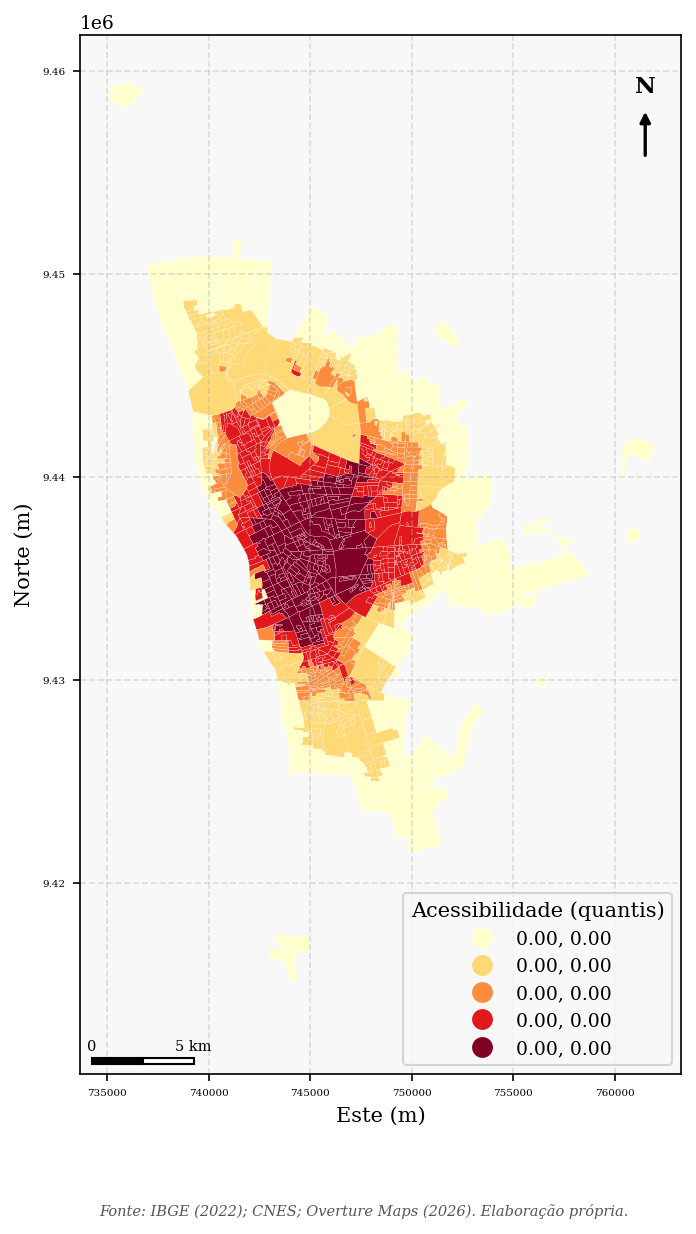

In [6]:
# ── Fig. 01 — Índice de acessibilidade AE2SFCA (automóvel) ──────────────────
fig, ax = plt.subplots(figsize=(9, 9))
setores.plot(ax=ax, column="acess_carro", scheme="quantiles", k=5, cmap="YlOrRd",
             legend=True, legend_kwds={"title": "Acessibilidade (quantis)", "loc": "lower right"},
             edgecolor="white", linewidth=0.1)
moldura_mapa(ax, "", "IBGE (2022); CNES; Overture Maps (2026). Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb051_fig01_ae2sfca_carro.png", bbox_inches="tight")
plt.show()

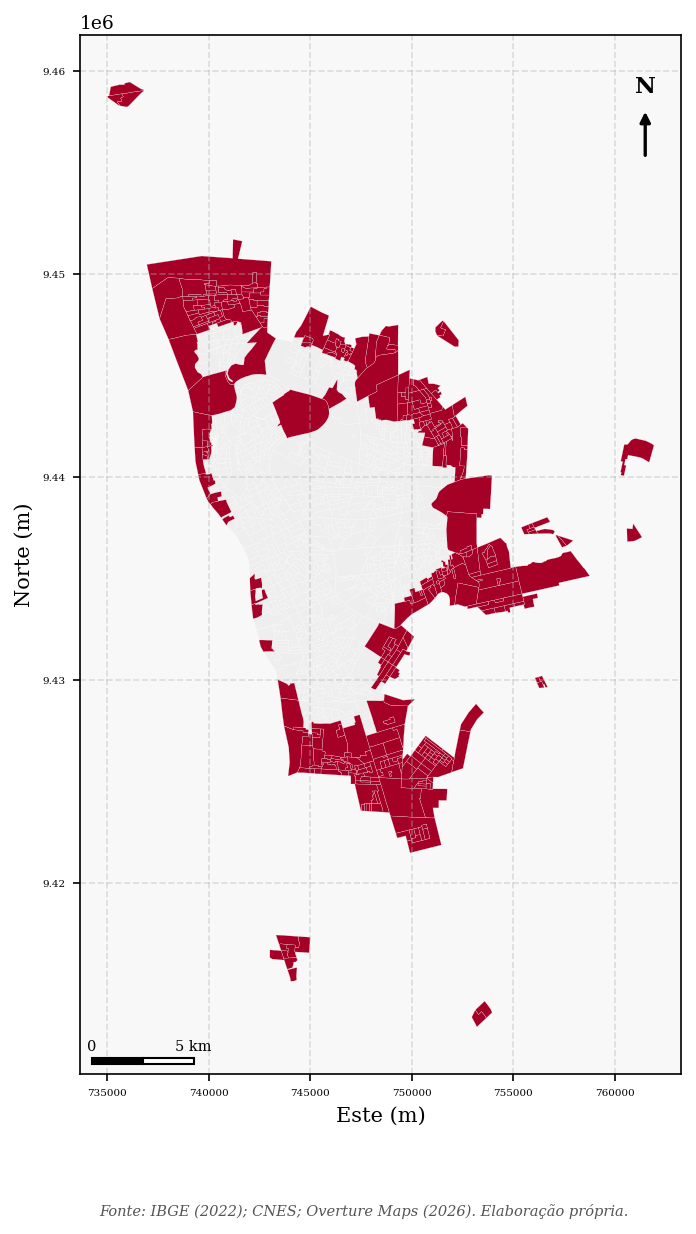

In [7]:
# ── Fig. 02 — Desertos de saúde (modo automóvel) ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1)
setores[setores["deserto_carro"]].plot(ax=ax, color="#A50026", edgecolor="white", linewidth=0.1)
moldura_mapa(ax, "", "IBGE (2022); CNES; Overture Maps (2026). Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb051_fig02_desertos_carro.png", bbox_inches="tight")
plt.show()

In [8]:
# ── 6. EXPORTAÇÃO ───────────────────────────────────────────────────────────
colunas = ["CD_SETOR", "populacao", "acess_carro", "acess_pe",
           "acess_carro_e2sfca", "deserto_carro", "deserto_pe", "geometry"]
saida = PROCESSADOS / "teresina_setores_acessibilidade.parquet"
setores[colunas].to_parquet(saida)
print(f"💾 Acessibilidade por setor salva: {saida}")

💾 Acessibilidade por setor salva: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\processados\teresina_setores_acessibilidade.parquet


---
## Próximos passos (NB 06)
- **Teste de H1**: comparar `acess_carro` (areal) × `acess_carro_e2sfca` (centroide) por
  correlação de Spearman e quantificar os setores reclassificados como deserto.
- **Teste de H2**: cruzar `acess_carro`/`acess_pe` com a renda média (variável a confirmar),
  via Spearman e autocorrelação espacial (Moran/LISA, biblioteca `esda`).